#Task 1:
The given dataset represents an - Image Classification problem. The images are organized into four folders: normal, scratch, dent, and stain, where each folder corresponds to a specific product condition or defect category. The objective is to train a CNN model that can classify an input image into one of these four classes. Since each image is assigned one label and there is no requirement to localize or segment defects, image classification is the most appropriate computer vision task for this dataset.

['normal', 'dent', 'scratch', 'stain']
Number of classes: 4
normal: 120 images
dent: 120 images
scratch: 120 images
stain: 120 images


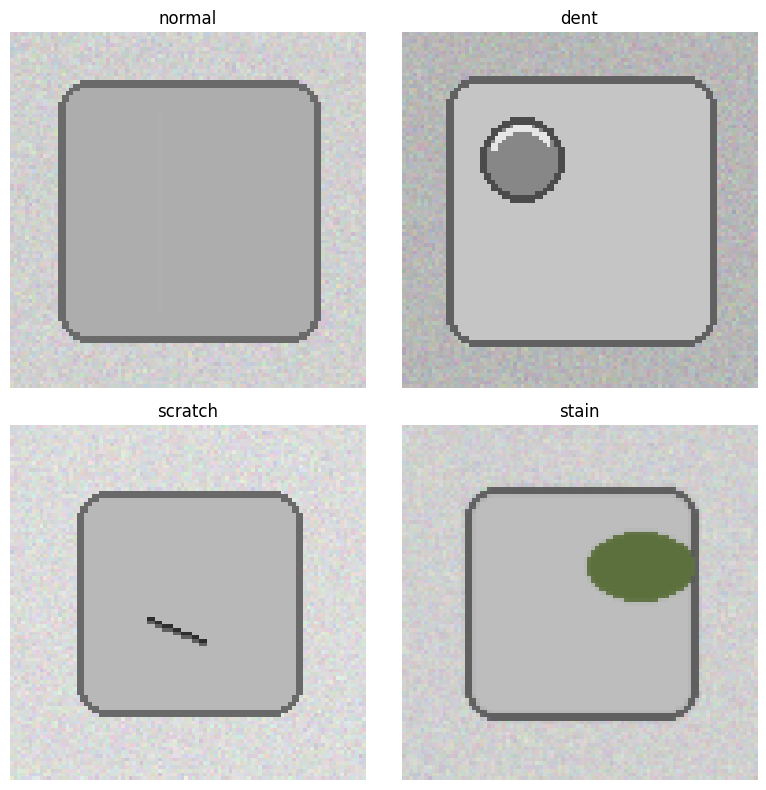

normal: (96, 96)
dent: (96, 96)
scratch: (96, 96)
stain: (96, 96)


In [10]:
#Task 2:

import zipfile
with zipfile.ZipFile('/images - Copy.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')
import os
classes = os.listdir('/content/images')

classes = [cls for cls in classes if cls != '.DS_Store']

print(classes)
print("Number of classes:", len(classes))


import matplotlib.pyplot as plt
from PIL import Image
base_path = "/content/images"
for cls in classes:
    folder_path = os.path.join(base_path, cls)
    num_images = len(os.listdir(folder_path))
    print(f"{cls}: {num_images} images")

plt.figure(figsize=(8,8))
for i, cls in enumerate(classes):
    img_name = os.listdir(os.path.join(base_path, cls))[0]
    img_path = os.path.join(base_path, cls, img_name)
    img = Image.open(img_path)
    plt.subplot(2,2,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")
plt.tight_layout()
plt.show()

for cls in classes:
    img_name = os.listdir(os.path.join(base_path, cls))[0]
    img_path = os.path.join(base_path, cls, img_name)
    img = Image.open(img_path)
    print(f"{cls}: {img.size}")




##Task 2:
The image dataset was explored before training the CNN model. The dataset contains 4 classes: normal, dent, scratch, and stain. Each class contains 120 images, resulting in a total of 480 images. Sample images from each class were visualized to understand defect patterns. All images had a consistent resolution of 96 × 96 pixels, making them suitable for CNN processing. Since each class contains an equal number of images, the dataset is balanced and no major class imbalance was observed.

In [11]:
#Task 3:

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixels
    validation_split=0.2,    # 80-20 split

    # augmentation
    rotation_range=10,
    horizontal_flip=True,
    zoom_range=0.1
)

train_generator = train_datagen.flow_from_directory(
    '/content/images',
    target_size=(96,96),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

test_generator = train_datagen.flow_from_directory(
    '/content/images',
    target_size=(96,96),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)




Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


## Task 3: Image Preprocessing

Images were resized to 96×96 pixels.
Pixel values were normalized between 0 and 1.
The dataset was split into training and testing sets using an 80:20 ratio.
Data augmentation was applied to improve generalization.

In [12]:
#Task 4:

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense

model = Sequential()

# Convolution + Activation + Pooling
model.add(Conv2D(
    filters=32,
    kernel_size=(3,3),
    activation='relu',
    input_shape=(96,96,3)
))

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Output Layer
model.add(Dense(4, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 70688)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     9,048,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,049,604 (34.52 MB)

 Trainable params: 9,049,604 (34.52 MB)

 Non-trainable params: 0 (0.00 B)

#Task 4:
A CNN model was created for multi-class image classification. The model begins with a convolution layer containing 32 filters of size 3×3 to extract visual features such as edges, textures, and defect patterns. A max pooling layer was used to reduce spatial dimensions and computational complexity. The flatten layer converted extracted feature maps into a one-dimensional vector. A dense layer with 128 neurons was used for learning higher-level feature representations. Finally, the output layer contains 4 neurons with softmax activation to classify images into normal, dent, scratch, and stain categories.

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 469ms/step - accuracy: 0.8229 - loss: 0.6564 - val_accuracy: 0.7396 - val_loss: 0.6731
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 526ms/step - accuracy: 0.8047 - loss: 0.6055 - val_accuracy: 0.8125 - val_loss: 0.6109
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 465ms/step - accuracy: 0.8255 - loss: 0.5459 - val_accuracy: 0.7812 - val_loss: 0.5257
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 443ms/step - accuracy: 0.8099 - loss: 0.5020 - val_accuracy: 0.7708 - val_loss: 0.5189
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 558ms/step - accuracy: 0.8203 - loss: 0.4905 - val_accuracy: 0.8333 - val_loss: 0.5190
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 422ms/step - accuracy: 0.7526 - loss: 0.5920 - val_accuracy: 0.7708 - val_loss: 0.6696
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 575ms/step - accuracy: 0.8438 - loss: 0.5119 - val_accuracy: 0.7812 - val_loss: 0.5102
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 435ms/step - accuracy: 0.8359 - loss: 0.4915 - val_accuracy: 0.

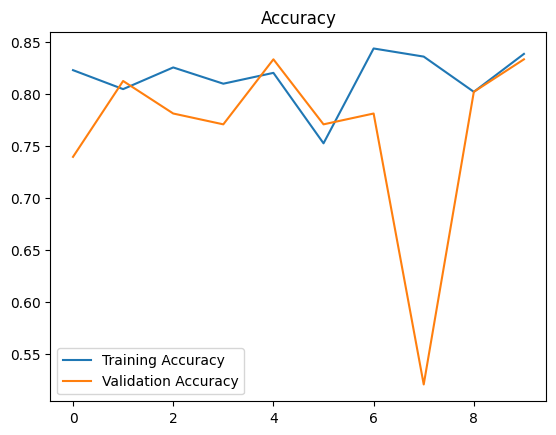

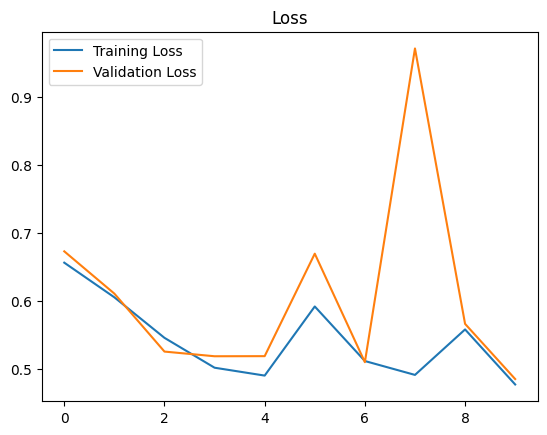

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.8646 - loss: 0.4733
Test Loss: 0.4733234643936157
Test Accuracy: 0.8645833134651184
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 255ms/step
[[7 6 4 7]
 [6 8 6 4]
 [5 5 7 7]
 [5 8 6 5]]
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step


<Figure size 640x480 with 0 Axes>

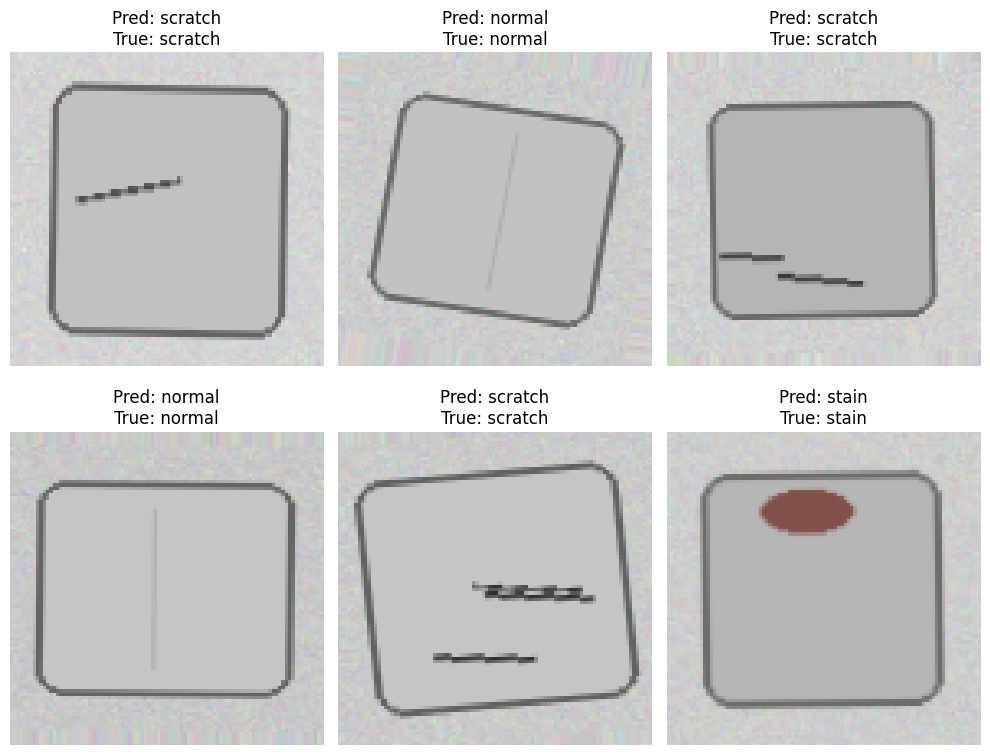

In [15]:
#Task 5:

history = model.fit(
    train_generator,
    validation_data=test_generator,
    epochs=10
)
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

# Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss")
plt.show()

test_loss, test_accuracy = model.evaluate(test_generator)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

import numpy as np
from sklearn.metrics import confusion_matrix

predictions = model.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes
cm = confusion_matrix(y_true, y_pred)
print(cm)
plt.savefig("confusion_matrix.png")

class_names = list(test_generator.class_indices.keys())
images, labels = next(test_generator)
predictions = model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(10,8))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i])
    plt.title(
        f"Pred: {class_names[predicted_classes[i]]}\n"
        f"True: {class_names[true_classes[i]]}"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()
